# Lỗi chồng lấp với native và blend 50/50 theo mô hình đơn đã chọn

[Bài 05](05_backbone_and_selection.ipynb) đã khóa một mô hình đơn trên 800 cặp phát triển. Bài này lấy đúng mô hình đó, căn ID với `native` trên OOF seed `20260917`, rồi đếm bốn nhóm đúng/sai. Sau khi thấy cơ hội và rủi ro mới tính trung bình xác suất 50/50.

Điểm cao hơn chưa cho biết hai mô hình sai trên cùng những cặp nào. Nếu native đúng ở một số cặp mô hình đã chọn làm sai, kết hợp chúng có thể hữu ích. Nhưng native cũng có thể làm hỏng những cặp vốn đã đúng. Ta đọc hai phía này trước khi tính blend.

Tỷ lệ 50/50 được cố định trước khi xem kết quả, theo phép thử fusion trong kế hoạch gốc. Việc xem lỗi ở đây giúp hiểu vì sao đáng thử và vì sao vẫn phải đo lại kết quả.

Quy tắc chọn blend: trung bình chưa làm tròn của ba seed phải đạt ít nhất +0.005 Macro-F1 so với mô hình đơn đã chọn. Seed nộp bài vẫn là `20260917`.


In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmd.core import read_json, metric
from kmd.pipeline import prepare_development, start_session, aligned_predictions, blend, compare_oof
from kmd.decision_flow import run_selected_blend_suite, verify_method_artifacts
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID
PRIMARY_SEED = 20260917
CONFIRM_SEEDS = (20260917, 20260918, 20260919)
MIN_GAIN = 0.005

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.name} (smoke={KMD_SMOKE})")
print(f"Tổng số cặp phát triển: {len(dev_frame)}")
if KMD_SMOKE:
    raise ValueError('Bài 06 cần KMD_SMOKE=0 và kết quả đủ ba seed từ bài 05.')


Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: lesson_full_v5_20260920 (smoke=False)
Tổng số cặp phát triển: 800


## 1. Mô hình đơn đã chọn và căn chỉnh OOF

`single_selection.json` do bài 05 ghi sau khi xác minh screening và confirmation. Bài này không train mạng mới. `verify_method_artifacts` kiểm tra dự đoán đã lưu với từng fold và checkpoint. Sau đó ta căn đúng 800 `pair_id` rồi mới so nhóm lỗi.

Nếu mô hình đơn là `native`, blend với chính native không thêm thông tin: API sẽ bỏ qua self-blend.


In [2]:
sel_path = session_dir / 'single_selection.json'
if not sel_path.is_file():
    raise FileNotFoundError(
        f"Chưa có {sel_path.name}. Chạy bài 05 với cùng KMD_RUN_ID và KMD_SMOKE=0."
    )

selection = read_json(sel_path)
winner = selection['method']
print('Mô hình đơn từ bài 05:')
for key in (
    'protocol', 'method', 'shortlist', 'confirmed_methods',
    'seed_for_submission', 'partition', 'private_used',
):
    print(f'  {key}: {selection.get(key)}')

if selection.get('seed_for_submission') != PRIMARY_SEED:
    raise ValueError('seed_for_submission phải là 20260917.')
if winner is None:
    raise ValueError('single_selection.json không có method.')

pred_win, _ = verify_method_artifacts(session_dir, winner, PRIMARY_SEED, dev_frame)
pred_nat, _ = verify_method_artifacts(session_dir, 'native', PRIMARY_SEED, dev_frame)

y_true = dev_frame.fake_position.to_numpy(dtype=int)
p_win = pred_win.p.to_numpy(dtype=float)
p_nat = pred_nat.p.to_numpy(dtype=float)
print(f'\nĐã căn {len(dev_frame)} cặp: winner={winner}, native, seed={PRIMARY_SEED}.')
print(f'Macro-F1 winner: {metric(y_true, p_win)["macro_f1"]:.6f} | lỗi {metric(y_true, p_win)["errors"]}')
print(f'Macro-F1 native: {metric(y_true, p_nat)["macro_f1"]:.6f} | lỗi {metric(y_true, p_nat)["errors"]}')


Mô hình đơn từ bài 05:
  protocol: backbone_flow_v1
  method: b2
  shortlist: ['dense288', 'b2']
  confirmed_methods: ['dense288', 'b2', 'center60', 'center60_cap48', 'native']
  seed_for_submission: 20260917
  partition: development
  private_used: False

Đã căn 800 cặp: winner=b2, native, seed=20260917.
Macro-F1 winner: 0.972500 | lỗi 22
Macro-F1 native: 0.966247 | lỗi 27


## 2. Bốn nhóm trên OOF seed 20260917

Mỗi cặp thuộc đúng một nhóm:
1. Cả hai đúng.
2. Chỉ mô hình đơn đúng, native sai.
3. Chỉ native đúng, mô hình đơn sai.
4. Cả hai sai.

Nhóm 3 là chỗ blend có thể sửa nếu native đủ tự tin kéo xác suất qua 0.5. Nhóm 2 là chỗ blend có thể làm hỏng. Nhóm 4: hai mô hình cùng chọn nhãn sai; trung bình 50/50 vẫn sai.

Tổng bốn nhóm phải bằng 800. `aligned_predictions` đã bắt ID thiếu hoặc thừa.


Bốn nhóm trên seed 20260917, winner=b2:
  Cả hai đúng: 758 cặp (94.8%)
  Chỉ winner đúng (native sai):  20 cặp (2.5%)
  Chỉ native đúng (winner sai):  15 cặp (1.9%)
  Cả hai sai:   7 cặp (0.9%)


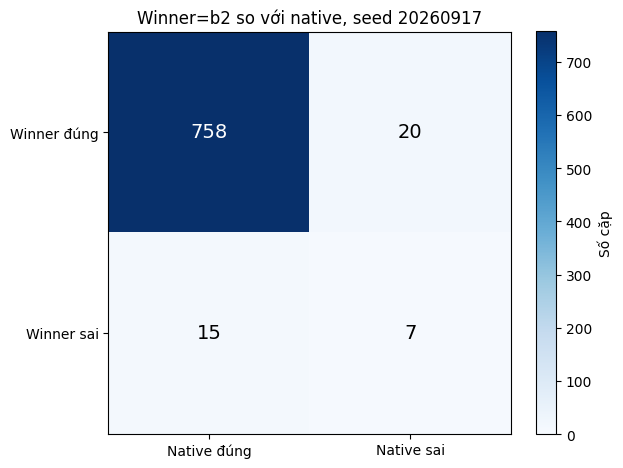

In [3]:
corr_win = (p_win >= 0.5) == y_true
corr_nat = (p_nat >= 0.5) == y_true

g_both_corr = corr_win & corr_nat
g_only_win = corr_win & (~corr_nat)
g_only_nat = (~corr_win) & corr_nat
g_both_wrong = (~corr_win) & (~corr_nat)

membership = (
    g_both_corr.astype(int) + g_only_win.astype(int)
    + g_only_nat.astype(int) + g_both_wrong.astype(int)
)
if membership.sum() != len(dev_frame) or not np.all(membership == 1):
    raise ValueError('Bốn nhóm phải phủ đúng 800 cặp, mỗi cặp một nhóm.')

groups = [
    ('Cả hai đúng', g_both_corr),
    ('Chỉ winner đúng (native sai)', g_only_win),
    ('Chỉ native đúng (winner sai)', g_only_nat),
    ('Cả hai sai', g_both_wrong),
]
print(f'Bốn nhóm trên seed {PRIMARY_SEED}, winner={winner}:')
for label, mask in groups:
    print(f'  {label}: {int(mask.sum()):3d} cặp ({mask.mean() * 100:.1f}%)')

counts = np.array([
    [int(g_both_corr.sum()), int(g_only_win.sum())],
    [int(g_only_nat.sum()), int(g_both_wrong.sum())],
], dtype=int)
fig, ax = plt.subplots(figsize=(6.2, 4.8))
im = ax.imshow(counts, cmap='Blues', vmin=0)
for (r, c), count in np.ndenumerate(counts):
    ax.text(c, r, str(count), ha='center', va='center', fontsize=14,
            color='white' if count > counts.max() / 2 else 'black')
ax.set(
    xticks=[0, 1], yticks=[0, 1],
    xticklabels=['Native đúng', 'Native sai'],
    yticklabels=['Winner đúng', 'Winner sai'],
    title=f'Winner={winner} so với native, seed {PRIMARY_SEED}',
)
fig.colorbar(im, ax=ax, label='Số cặp')
plt.tight_layout()
plt.show()


## 3. Một cặp đầu tiên theo `pair_id` trong từng nhóm

Trong mỗi nhóm, lấy `pair_id` nhỏ nhất theo thứ tự sắp xếp của bảng. Nếu nhóm rỗng, in thông báo rồi bỏ qua, không lấy mẫu nhóm khác thay thế. Nhóm cả hai sai cũng được xem, vì blend 50/50 không sửa được khi hai phía cùng chọn nhãn sai.


Cả hai đúng | cặp 00001
winner p=1.000 | native p=1.000


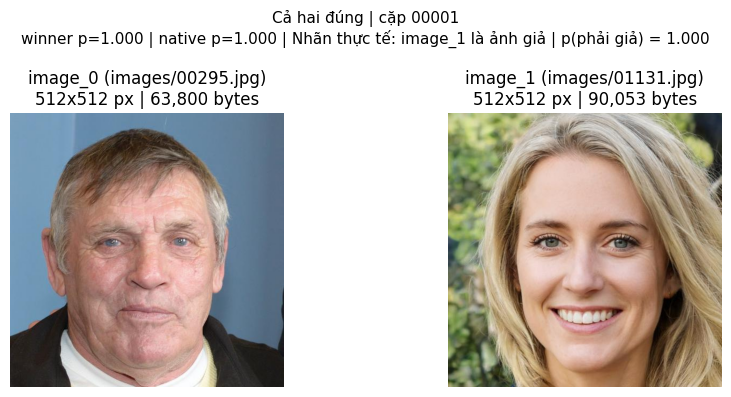

Chỉ winner đúng (native sai) | cặp 00011
winner p=0.002 | native p=0.752


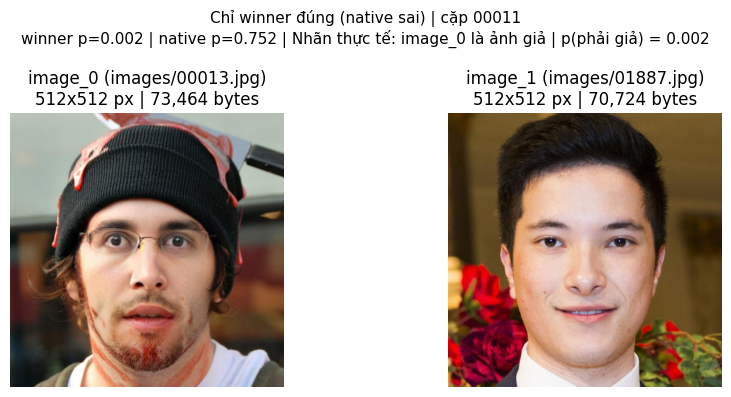

Chỉ native đúng (winner sai) | cặp 00122
winner p=0.910 | native p=0.000


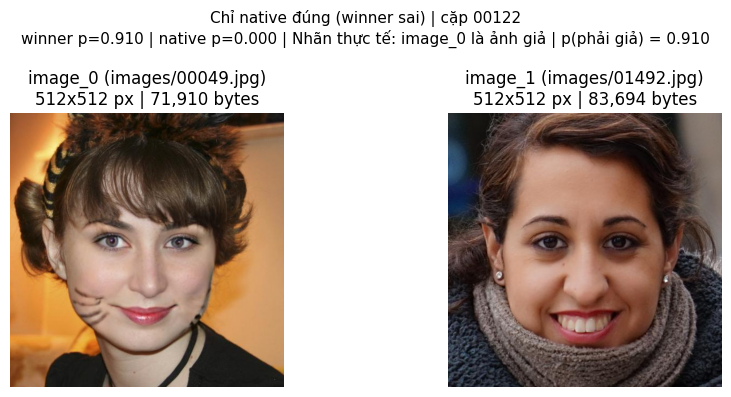

Cả hai sai | cặp 00092
winner p=0.000 | native p=0.001


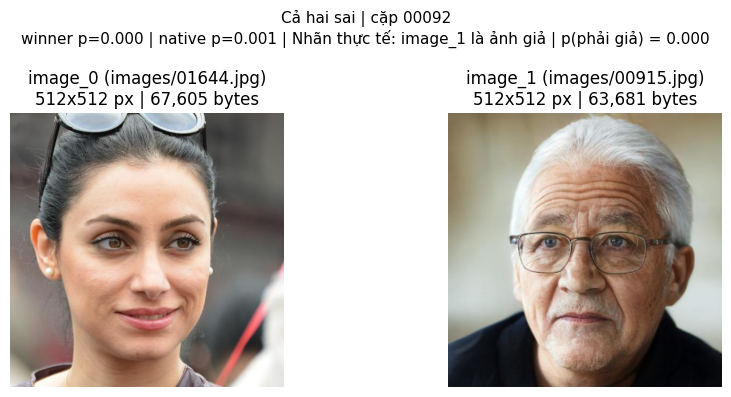

In [4]:
for group_name, mask in groups:
    subset = dev_frame.loc[mask].sort_values('pair_id')
    if subset.empty:
        print(f'{group_name}: không có cặp nào trên seed {PRIMARY_SEED}.')
        continue
    row = subset.iloc[0]
    pos = int(np.where(dev_frame.pair_id.to_numpy() == row.pair_id)[0][0])
    cap = (
        f"{group_name} | cặp {row.pair_id}\n"
        f"winner p={p_win[pos]:.3f} | native p={p_nat[pos]:.3f}"
    )
    print(cap)
    show_pair_images(row, data_root, title=cap, p_pred=float(p_win[pos]))


## 4. Cơ hội, rủi ro, rồi trung bình 50/50

Nhóm chỉ native đúng là cơ hội. Nhóm chỉ winner đúng là rủi ro. Tỷ lệ 50/50 được giữ cố định, không tinh chỉnh trọng số trên validation.

$$p_{\mathrm{blend}} = 0.5 \cdot p_{\mathrm{winner}} + 0.5 \cdot p_{\mathrm{native}}$$

Đây là trung bình xác suất thật, không phải oracle lấy phía đúng ở mỗi cặp. Khi hai xác suất cùng phía ngưỡng 0.5, blend giữ quyết định đó. Khi hai phía bất đồng, phía xa 0.5 hơn kéo quyết định chung.

Trên mỗi seed đếm số ca sửa (`winner` sai, blend đúng), số ca làm hỏng (`winner` đúng, blend sai), số lỗi và Macro-F1. Chọn blend khi trung bình chưa làm tròn của ba giá trị $\Delta_s = \text{F1}_{\text{blend},s} - \text{F1}_{\text{winner},s}$ đạt ít nhất $+0.005$. Ngưỡng này là quyết định chi phí thêm một mạng, không phải kiểm định ý nghĩa thống kê.

Nếu winner là `native`, bỏ self-blend.

`run_selected_blend_suite` đọc selection và confirmation đã xác minh, không train thêm, ghi `selected_blend_comparison.csv` và `submission_decision.json`.


In [5]:
def seed_blend_stats(seed, winner_name, smoke):
    frame = dev_frame
    aligned_w, _ = verify_method_artifacts(session_dir, winner_name, seed, frame, smoke=smoke)
    aligned_n, _ = verify_method_artifacts(session_dir, 'native', seed, frame, smoke=smoke)
    y = frame.fake_position.to_numpy(dtype=int)
    pw = aligned_w.p.to_numpy(dtype=float)
    pn = aligned_n.p.to_numpy(dtype=float)
    pb = 0.5 * pw + 0.5 * pn
    via_helper = blend(aligned_w, aligned_n, frame)
    if not np.allclose(via_helper.p.to_numpy(dtype=float), pb):
        raise ValueError(f'Seed {seed}: blend() khác 0.5 * winner + 0.5 * native.')
    sc_w, sc_n, sc_b = metric(y, pw), metric(y, pn), metric(y, pb)
    corr_w = (pw >= 0.5) == y
    corr_b = (pb >= 0.5) == y
    n_fixed = int((~corr_w & corr_b).sum())
    n_broken = int((corr_w & ~corr_b).sum())
    return {
        'seed': seed,
        'winner_f1': sc_w['macro_f1'],
        'native_f1': sc_n['macro_f1'],
        'blend_f1': sc_b['macro_f1'],
        'delta_f1': sc_b['macro_f1'] - sc_w['macro_f1'],
        'winner_errors': sc_w['errors'],
        'native_errors': sc_n['errors'],
        'blend_errors': sc_b['errors'],
        'fixed': n_fixed,
        'broken': n_broken,
    }

self_blend = winner == 'native'
if self_blend:
    print(f'Winner là native: bỏ blend với chính nó. Seed nộp bài vẫn {PRIMARY_SEED}.')
    seed_rows = []
else:
    print(f'p_blend = 0.5 * p_{winner} + 0.5 * p_native trên từng seed.')
    seed_rows = [seed_blend_stats(seed, winner, smoke=KMD_SMOKE) for seed in CONFIRM_SEEDS]
    df_seeds = pd.DataFrame(seed_rows)
    print(df_seeds.to_string(index=False))
    gains = df_seeds['delta_f1'].to_numpy(dtype=float)
    if gains.shape != (3,) or not np.isfinite(gains).all():
        raise ValueError('Cần đúng 3 delta hữu hạn.')
    mean_gain = float(gains.mean())
    print('\nDelta từng seed (chưa làm tròn):', [float(v) for v in gains])
    print(f'Trung bình chưa làm tròn: {mean_gain:.12f}')
    print(f'Cổng +{MIN_GAIN}: {"đạt" if mean_gain >= MIN_GAIN else "không đạt"}')

print(
    '\nGọi run_selected_blend_suite '
    f'(smoke={KMD_SMOKE}). Cần KMD_SMOKE=0 để khóa quyết định nộp.'
)
table_blend, decision = run_selected_blend_suite(
    dev_frame, data_root, session_dir, smoke=KMD_SMOKE
)

if KMD_SMOKE or decision is None:
    print('Smoke hoặc artifact chưa đủ: decision=None. Không khóa blend.')
    print(table_blend)
else:
    print('\nBảng blend API:')
    print(table_blend.to_string(index=False))
    print('\nsubmission_decision:')
    for key in (
        'protocol', 'method', 'best_single', 'blend_delta_vs_best_single',
        'minimum_gain', 'components', 'weights', 'blend_status',
        'seed_for_submission', 'comparison_methods', 'private_used',
    ):
        print(f'  {key}: {decision.get(key)}')

    if self_blend:
        assert decision['method'] == 'native'
        assert decision['blend_status'] == 'skipped_self_blend'
    else:
        expected_method = 'blend_selected_native' if mean_gain >= MIN_GAIN else winner
        assert decision['method'] == expected_method
        assert abs(decision['blend_delta_vs_best_single'] - mean_gain) < 1e-12
    print(f"Quyết định development: {decision['method']}")


p_blend = 0.5 * p_b2 + 0.5 * p_native trên từng seed.


    seed  winner_f1  native_f1  blend_f1  delta_f1  winner_errors  native_errors  blend_errors  fixed  broken
20260917    0.97250   0.966247  0.979998  0.007498             22             27            16     14       8
20260918    0.98125   0.965000  0.982500  0.001250             15             28            14      8       7
20260919    0.97375   0.961245  0.978749  0.005000             21             31            17     11       7

Delta từng seed (chưa làm tròn): [0.007498171676054155, 0.0012498261646451958, 0.004999539035264955]
Trung bình chưa làm tròn: 0.004582512292
Cổng +0.005: không đạt

Gọi run_selected_blend_suite (smoke=False). Cần KMD_SMOKE=0 để khóa quyết định nộp.



Bảng blend API:
                          model                  arch     seed  smoke   n  macro_f1  accuracy      auc  log_loss  errors  rescued  broken
                   b2_s20260917                    b2 20260917  False 800  0.972500   0.97250 0.995419  0.102290      22      NaN     NaN
               native_s20260917                native 20260917  False 800  0.966247   0.96625 0.994441  0.197899      27      NaN     NaN
blend_selected_native_s20260917 blend_selected_native 20260917  False 800  0.979998   0.98000 0.996888  0.076524      16     14.0     8.0
                   b2_s20260918                    b2 20260918  False 800  0.981250   0.98125 0.994938  0.096488      15      NaN     NaN
               native_s20260918                native 20260918  False 800  0.965000   0.96500 0.995078  0.184231      28      NaN     NaN
blend_selected_native_s20260918 blend_selected_native 20260918  False 800  0.982500   0.98250 0.997094  0.068426      14      8.0     7.0
                 

### Đọc kết quả và chọn seed nộp bài

`blend_selected_native` nghĩa là trung bình ba seed đạt +0.005. Một seed lẻ vẫn có thể tăng ít hơn hoặc âm. Giữ mô hình đơn nghĩa là mức tăng trung bình chưa đủ theo quy tắc chi phí đã đặt. `skipped_self_blend` nghĩa là winner đã là native.

Seed nộp bài là `20260917`, chọn trước. Không lấy seed có F1 đẹp nhất. Ba seed mô tả biến thiên huấn luyện trên cùng bộ chia phát triển.

Nếu mức tăng không đạt ngưỡng, ta vẫn giữ bảng blend để thấy phép thử đã thay đổi lỗi ra sao. Quyết định nộp bài tiếp tục dùng mô hình đơn đã chọn ở bài 05.


## 5. Chốt trên development trước private

`submission_decision.json` là công thức blend (hoặc lý do bỏ blend) dùng ở bước khóa. [Bài 07](07_private_and_submission.ipynb) đọc quyết định đã xác minh, không mở nhãn private để chọn lại mô hình.

Nếu muốn đối chiếu phụ lục A-D trên private, chạy phụ lục trước bước khóa ở bài 07 và đặt `KMD_INCLUDE_EXTENSIONS=1`. Phụ lục C và D vẫn là phép thử cố định trên EfficientNet-B2 288px, không thay bằng mô hình đơn hay blend vừa chọn.
